In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="ticks")
from sklearn.datasets import load_wine
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета 
wine = load_wine()

In [5]:
data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
data['target'] = wine.target

print(f"Размер датасета: {data.shape}")
print(f"Количество пропусков до модификации:\n{data.isnull().sum()}")
print(f"\nТипы данных:\n{data.dtypes}")
print(f"\nУникальные значения target: {data['target'].unique()}")

Размер датасета: (178, 14)
Количество пропусков до модификации:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Типы данных:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             f

Так как у нас отсувтвуют пропуски, а по заданию необходимо обработать пропуски, то создадим пропуски искуственно

In [8]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


В параметре alcohol изменим 10% данных на Nan

In [29]:
np.random.seed(42)
alcohol_missing_idx = np.random.choice(
    data.index, 
    size=int(len(data) * 0.1), 
    replace=False
)
data.loc[alcohol_missing_idx, 'alcohol'] = np.nan

В силу того, что в датасете нет качественных признаком, то создадим колонку и сперва заполним данными flavanoids_category

In [21]:
def create_flavanoids_category(x):
    if pd.isna(x):
        return np.nan
    elif x < 1.5:
        return 'low'
    elif x < 3.0:
        return 'medium'
    else:
        return 'high'

data['flavanoids_category'] = data['flavanoids'].apply(create_flavanoids_category)

In [25]:
# Добавляем пропуски в созданный категориальный признак (~5%)
cat_missing_idx = np.random.choice(
    data.index, 
    size=int(len(data) * 0.05), 
    replace=False
)
data.loc[cat_missing_idx, 'flavanoids_category'] = np.nan

In [31]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,flavanoids_category
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,high
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,medium
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,high
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,high
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,medium


Заполение количественных признаков 

In [34]:
# проверим есть ли пропущенные значения
data.isnull().sum()

alcohol                         17
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                    0
flavanoids                       0
nonflavanoid_phenols             0
proanthocyanins                  0
color_intensity                  0
hue                              0
od280/od315_of_diluted_wines     0
proline                          0
target                           0
flavanoids_category             16
dtype: int64

In [38]:
# Выберем числовые колонки с пропущенными значениями

total_count = data.shape[0]
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка alcohol. Тип данных float64. Количество пустых значений 17, 9.55%.


In [42]:
data_num = data[num_cols]

data_num_alcohol = data_num[['alcohol']]
data_num_alcohol.head()

,alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24


In [44]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_alcohol)
mask_missing_values_only

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [46]:

strategies=['mean', 'median', 'most_frequent']

In [48]:

def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_alcohol)
    return data_num_imp[mask_missing_values_only]

In [54]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([12.99267081, 12.99267081, 12.99267081, 12.99267081, 12.99267081,
        12.99267081, 12.99267081, 12.99267081, 12.99267081, 12.99267081,
        12.99267081, 12.99267081, 12.99267081, 12.99267081, 12.99267081,
        12.99267081, 12.99267081]))

In [56]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05,
        13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05]))

In [58]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05,
        13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05, 13.05]))

In [64]:
num_imputer = SimpleImputer(strategy='mean')

# Импутация только для колонок с пропусками
data_num_imputed = num_imputer.fit_transform(data[num_cols])

# Заменяем исходные данные импутированными
for i, col in enumerate(num_cols):
    data[col] = data_num_imputed[:, i]

In [66]:
# проверим есть ли пропущенные значения
data.isnull().sum()

alcohol                          0
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                    0
flavanoids                       0
nonflavanoid_phenols             0
proanthocyanins                  0
color_intensity                  0
hue                              0
od280/od315_of_diluted_wines     0
proline                          0
target                           0
flavanoids_category             16
dtype: int64

А теперь заполним категорийные признаки

In [68]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка flavanoids_category. Тип данных object. Количество пустых значений 16, 8.99%.


In [70]:
cat_temp_data = data[['flavanoids_category']]
cat_temp_data.head()

,flavanoids_category
0,high
1,medium
2,high
3,high
4,medium


In [72]:
cat_temp_data['flavanoids_category'].unique()

array(['high', 'medium', nan, 'low'], dtype=object)

In [74]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['high'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['high'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['high'],
       ['high'],
       ['high'],
       ['high'],
       ['high'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['high'],
       ['high'],
       ['medium'],
       ['high'],
       ['medium'],
       ['medium'],

In [76]:

# Пустые значения отсутствуют
np.unique(data_imp2)

array(['high', 'low', 'medium'], dtype=object)

In [80]:
data['flavanoids_category'] = data_imp2.flatten()

# Проверить, что пропусков больше нет
data.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
flavanoids_category             0
dtype: int64

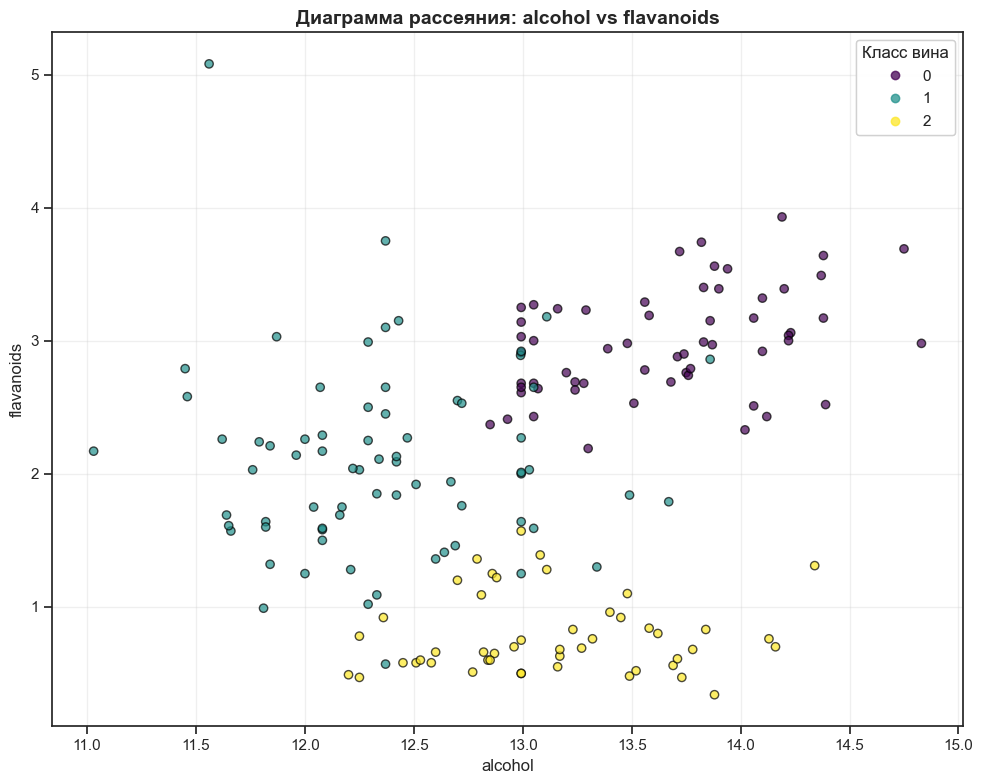

In [108]:
# ДИАГРАММА РАССЕЯНИЯ (SCATTER PLOT)

#Выбираем две произвольные колонки: 'alcohol' и 'flavanoids'
# Используем импутированные данные для корректного отображения

fig, ax = plt.subplots(figsize=(10, 8))

# Создаем scatter plot и сохраняем в переменную
scatter = ax.scatter(data['alcohol'], data['flavanoids'], 
                     c=data['target'], 
                     cmap='viridis',  
                     edgecolors='black',
                     alpha=0.7)

ax.set_xlabel('alcohol', fontsize=12)
ax.set_ylabel('flavanoids', fontsize=12)
ax.set_title('Диаграмма рассеяния: alcohol vs flavanoids', fontsize=14, fontweight='bold')

# Добавляем легенду для классов
legend1 = ax.legend(*scatter.legend_elements(), title="Класс вина")
ax.add_artist(legend1)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

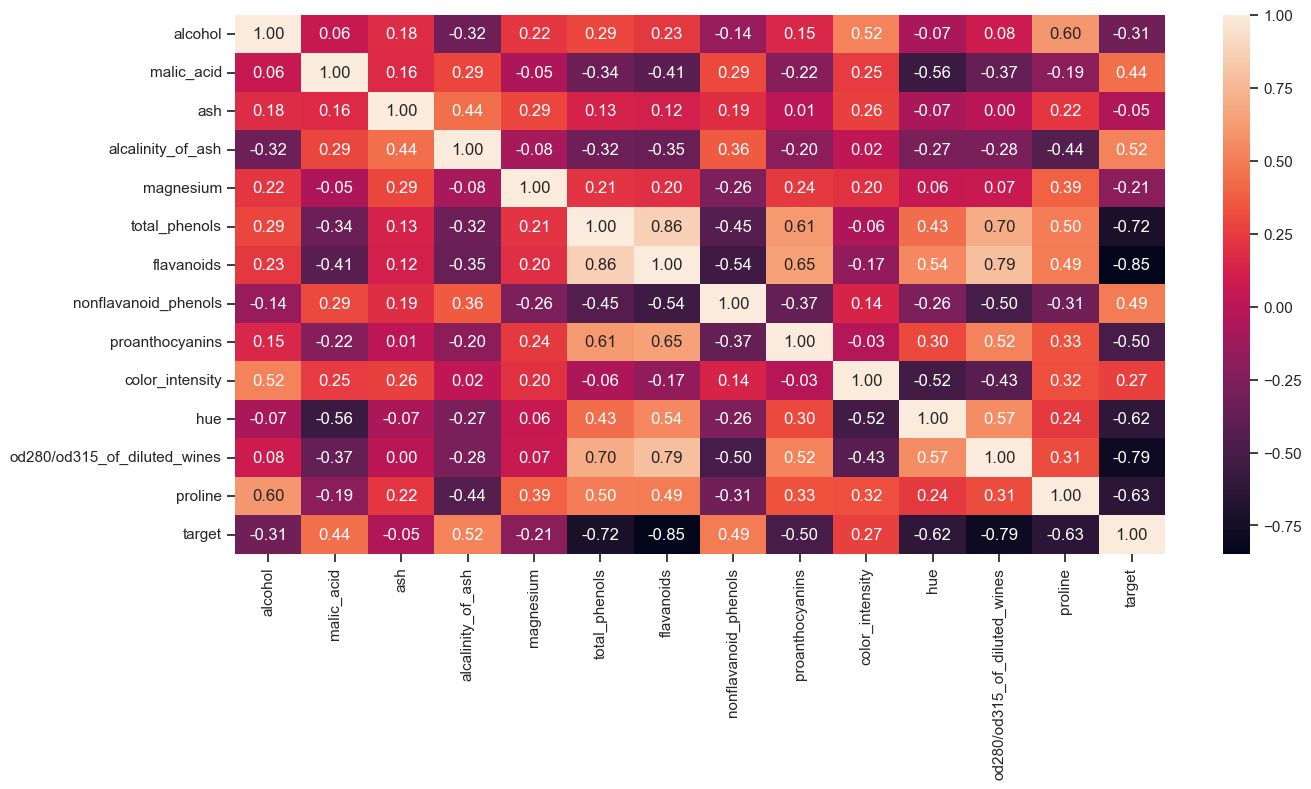

In [110]:

# Выбираем только числовые колонки
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
data_numeric = data[numeric_columns].copy()

# Построим корреляционную матрицу
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(data_numeric.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')
plt.show()